# NFL EPA Model - Data Exploration

**Phase 2a: EPA Model Development**

This notebook explores the nflfastR play-by-play data (2016-2024) to understand:
1. Data structure and key columns
2. Expected Points (EP) distribution by field position
3. Down and distance patterns
4. Identifying blowout games for filtering
5. Data quality issues

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 1000)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 1. Load Data

In [2]:
# Load combined data
print("Loading data...")
pbp = pd.read_parquet('../data/play_by_play_2016_2024.parquet')

print(f"✓ Loaded {len(pbp):,} plays")
print(f"  Seasons: {sorted(pbp['season'].unique().tolist())}")
print(f"  Columns: {len(pbp.columns)}")
print(f"  Memory: {pbp.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Loading data...
✓ Loaded 435,483 plays
  Seasons: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
  Columns: 396
  Memory: 1437.5 MB


## 2. Understand Data Structure

In [3]:
# Display basic info
print("Dataset shape:", pbp.shape)
print("\nFirst few rows:")
pbp.head()

Dataset shape: (435483, 396)

First few rows:


,play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,side_of_field,yardline_100,game_date,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining,game_half,quarter_end,drive,sp,qtr,down,goal_to_go,time,yrdln,ydstogo,ydsnet,desc,play_type,yards_gained,shotgun,no_huddle,qb_dropback,qb_kneel,qb_spike,qb_scramble,pass_length,pass_location,air_yards,yards_after_catch,run_location,run_gap,field_goal_result,kick_distance,extra_point_result,two_point_conv_result,home_timeouts_remaining,away_timeouts_remaining,timeout,timeout_team,...,receiver_jersey_number,pass,rush,first_down,special,play,passer_id,rusher_id,receiver_id,name,jersey_number,id,fantasy_player_name,fantasy_player_id,fantasy,fantasy_id,out_of_bounds,home_opening_kickoff,qb_epa,xyac_epa,xyac_mean_yardage,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe,nflverse_game_id,possession_team,offense_formation,offense_personnel,defenders_in_box,defense_personnel,number_of_pass_rushers,players_on_play,offense_players,defense_players,n_offense,n_defense,ngs_air_yards,time_to_throw,was_pressure,route,defense_man_zone_type,defense_coverage_type,offense_names,defense_names,offense_positions,defense_positions,offense_numbers,defense_numbers
0,1.0,2016_01_BUF_BAL,2016091101,BAL,BUF,REG,1,NaN,NaN,NaN,NaN,NaN,2016-09-11,900.0,1800.0,3600.0,Half1,0.0,NaN,0.0,1.0,NaN,0,15:00,BUF 35,0.0,NaN,GAME,NaN,NaN,0.0,0.0,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,NaN,NaN,...,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016_01_BUF_BAL,,NaN,NaN,NaN,NaN,NaN,,,,0.0,0.0,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,36.0,2016_01_BUF_BAL,2016091101,BAL,BUF,REG,1,BAL,home,BUF,BUF,35.0,2016-09-11,900.0,1800.0,3600.0,Half1,0.0,1.0,0.0,1.0,NaN,0,15:00,BUF 35,0.0,15.0,4-Gay kicks 65 yards from BUF 35 to BAL 0. 14-...,kickoff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.0,NaN,NaN,3.0,3.0,0.0,NaN,...,NaN,0.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,-0.955114,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016_01_BUF_BAL,BUF,NaN,NaN,NaN,NaN,NaN,40078;40151;37977;36060;40494;40053;40253;4011...,00-0030041;00-0030073;00-0029799;00-0030433;00...,00-0029892;00-0029895;00-0028497;00-0027539;00...,10.0,11.0,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,58.0,2016_01_BUF_BAL,2016091101,BAL,BUF,REG,1,BAL,home,BUF,BAL,86.0,2016-09-11,897.0,1797.0,3597.0,Half1,0.0,1.0,0.0,1.0,1.0,0,14:57,BAL 14,10.0,15.0,(14:57) 29-J.Forsett right end pushed ob at BA...,run,6.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,right,end,NaN,NaN,NaN,NaN,3.0,3.0,0.0,NaN,...,NaN,0.0,1.0,0.0,0.0,1.0,NaN,00-0026373,NaN,J.Forsett,29.0,00-0026373,J.Forsett,00-0026373,J.Forsett,00-0026373,1.0,1.0,0.336466,NaN,NaN,NaN,NaN,NaN,0.460759,-46.075901,2016_01_BUF_BAL,BAL,I_FORM,"2 RB, 1 TE, 2 WR",8.0,"4 DL, 3 LB, 4 DB",NaN,38540;41302;40078;35553;38582;43295;40053;4336...,00-0029892;00-0027714;00-0032965;00-0029893;00...,00-0029542;00-0031171;00-0029566;00-0030073;00...,11.0,11.0,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,85.0,2016_01_BUF_BAL,2016091101,BAL,BUF,REG,1,BAL,home,BUF,BAL,80.0,2016-09-11,872.0,1772.0,3572.0,Half1,0.0,1.0,0.0,1.0,2.0,0,14:32,BAL 20,4.0,15.0,"(14:32) (No Huddle, Shotgun) 5-J.Flacco pass s...",pass,5.0,1.0,1.0,1.0,0.0,0.0,0.0,short,right,-4.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,0.0,NaN,...,29.0,1.0,0.0,1.0,0.0,1.0,00-0026158,NaN,00-0026373,J.Flacco,5.0,00-0026158,J.Forsett,00-0026373,J.Forsett,00-0026373,0.0,1.0,0.644540,1.567466,9.753489,8.0,0.63767,0.530295,0.426425,57.357510,2016_01_BUF_BAL,BAL,SHOTGUN,"2 RB, 1 TE, 2 WR",6.0,"4 DL, 3 LB, 4 DB",3.0,41302;40078;38540;35553;43295;38582;40053;4336...,00-0029892;00-0027714;00-0032965;00-0029893;00...,00-0031171;00-0029542;00-0029566;00-0030073;00...,11.0,11.0,-4.53,2.404,False,FLAT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,109.0,2016_01_BUF_BAL,2016091101,BAL,BUF,REG,1,BAL,home,BUF,BAL,75.0,2016-09-11,841.0,1741.0,3541.0

In [4]:
# Key columns for EPA model
epa_columns = [
    'play_id', 'game_id', 'season', 'week',
    'posteam', 'defteam', 'home_team', 'away_team',
    'down', 'ydstogo', 'yardline_100',
    'quarter', 'quarter_seconds_remaining', 'game_seconds_remaining',
    'posteam_score', 'defteam_score', 'score_differential',
    'ep', 'epa', 'wp', 'vegas_wp',
    'play_type', 'touchdown', 'fumble', 'interception',
    'penalty', 'qb_kneel', 'qb_spike'
]

print("Key columns for EPA model:")
print("\n".join(epa_columns))

# Check if all columns exist
missing_cols = [col for col in epa_columns if col not in pbp.columns]
if missing_cols:
    print(f"\n⚠️  Missing columns: {missing_cols}")
else:
    print("\n✓ All key columns present")

Key columns for EPA model:
play_id
game_id
season
week
posteam
defteam
home_team
away_team
down
ydstogo
yardline_100
quarter
quarter_seconds_remaining
game_seconds_remaining
posteam_score
defteam_score
score_differential
ep
epa
wp
vegas_wp
play_type
touchdown
fumble
interception
penalty
qb_kneel
qb_spike

⚠️  Missing columns: ['quarter']


In [ ]:
# Check for missing values in key columns
key_cols = ['down', 'ydstogo', 'yardline_100', 'ep', 'wp']
print("Missing values in key columns:")
print(pbp[key_cols].isnull().sum())
print(f"\nTotal plays: {len(pbp):,}")
print(f"Plays with EP: {pbp['ep'].notna().sum():,}")
print(f"Plays with WP: {pbp['wp'].notna().sum():,}")

## 3. Explore Expected Points Distribution

Plays with EP values: 430,501 (98.9%)


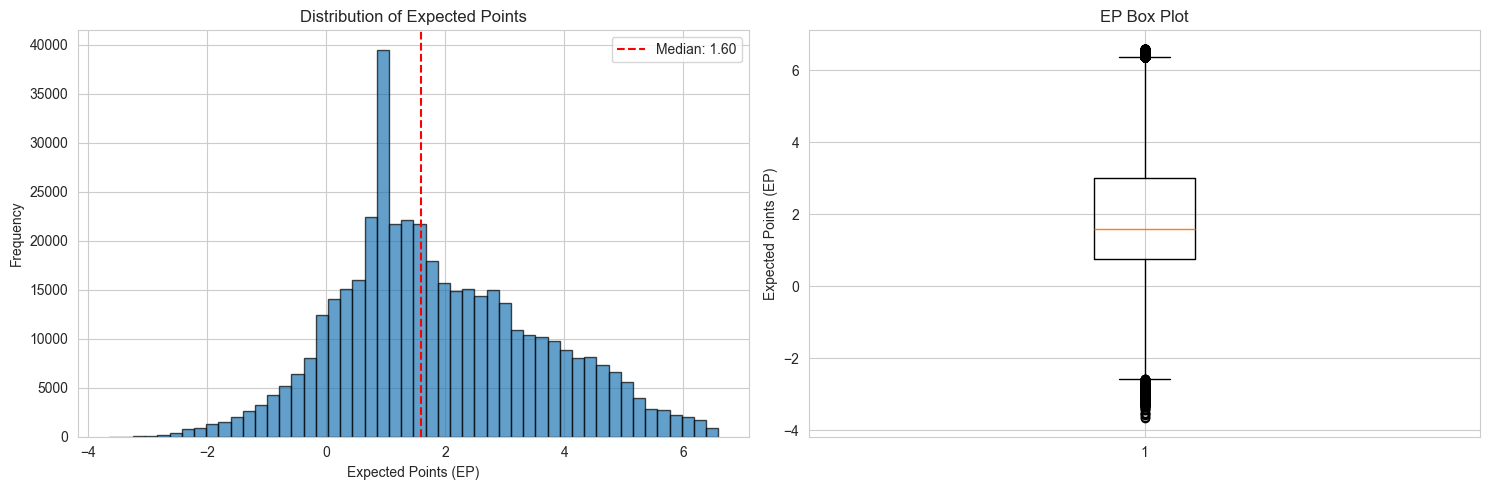


EP Statistics:
count    430501.000000
mean          1.891236
std           1.697991
min          -3.661654
25%           0.770222
50%           1.596795
75%           3.006146
max           6.593666
Name: ep, dtype: float64


In [5]:
# Filter to plays with EP values
pbp_with_ep = pbp[pbp['ep'].notna()].copy()
print(f"Plays with EP values: {len(pbp_with_ep):,} ({len(pbp_with_ep)/len(pbp)*100:.1f}%)")

# EP distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(pbp_with_ep['ep'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Expected Points (EP)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Expected Points')
axes[0].axvline(pbp_with_ep['ep'].median(), color='red', linestyle='--', label=f'Median: {pbp_with_ep["ep"].median():.2f}')
axes[0].legend()

# Box plot
axes[1].boxplot(pbp_with_ep['ep'], vert=True)
axes[1].set_ylabel('Expected Points (EP)')
axes[1].set_title('EP Box Plot')

plt.tight_layout()
plt.show()

print(f"\nEP Statistics:")
print(pbp_with_ep['ep'].describe())

## 4. EP by Field Position

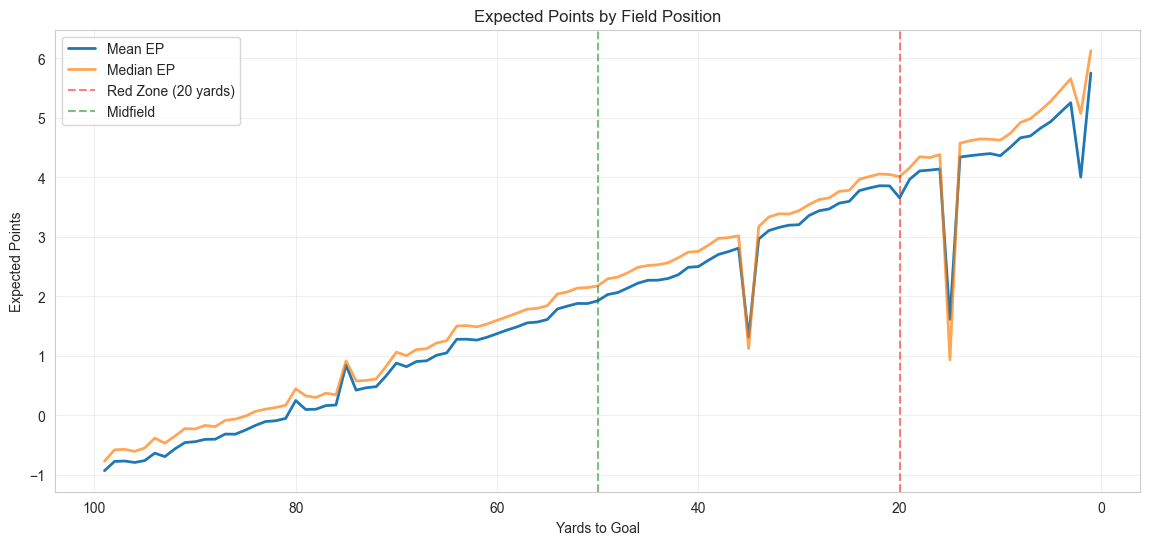

Key observations:
  EP at own 1-yard line: -0.93
  EP at midfield: 1.92
  EP at opponent 20 (red zone): 3.66
  EP at opponent 1-yard line: 5.75


In [6]:
# Group by field position (yardline_100)
ep_by_position = pbp_with_ep.groupby('yardline_100')['ep'].agg(['mean', 'median', 'count']).reset_index()

# Plot EP by field position
plt.figure(figsize=(14, 6))
plt.plot(ep_by_position['yardline_100'], ep_by_position['mean'], label='Mean EP', linewidth=2)
plt.plot(ep_by_position['yardline_100'], ep_by_position['median'], label='Median EP', linewidth=2, alpha=0.7)
plt.axvline(20, color='red', linestyle='--', alpha=0.5, label='Red Zone (20 yards)')
plt.axvline(50, color='green', linestyle='--', alpha=0.5, label='Midfield')
plt.xlabel('Yards to Goal')
plt.ylabel('Expected Points')
plt.title('Expected Points by Field Position')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().invert_xaxis()  # Invert x-axis so goal line is on the right
plt.show()

print("Key observations:")
print(f"  EP at own 1-yard line: {ep_by_position[ep_by_position['yardline_100']==99]['mean'].values[0]:.2f}")
print(f"  EP at midfield: {ep_by_position[ep_by_position['yardline_100']==50]['mean'].values[0]:.2f}")
print(f"  EP at opponent 20 (red zone): {ep_by_position[ep_by_position['yardline_100']==20]['mean'].values[0]:.2f}")
print(f"  EP at opponent 1-yard line: {ep_by_position[ep_by_position['yardline_100']==1]['mean'].values[0]:.2f}")

## 5. EP by Down and Distance

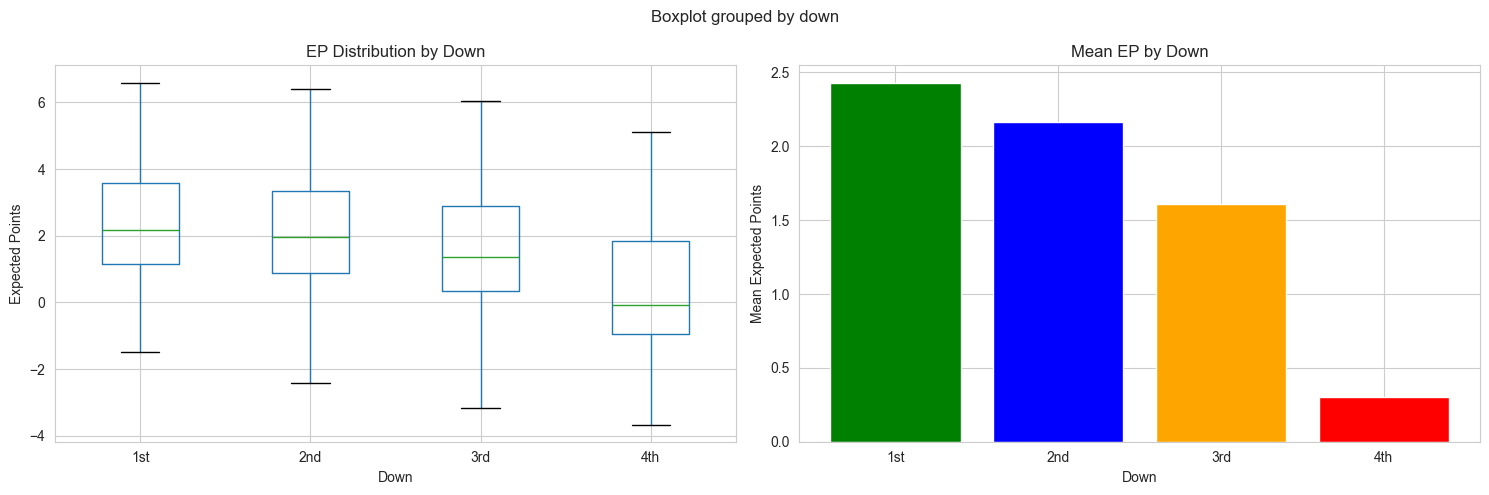


Mean EP by down:
down
1.0    2.425781
2.0    2.164958
3.0    1.608381
4.0    0.302455
Name: ep, dtype: float32


In [7]:
# Filter to valid downs (1-4)
pbp_valid_down = pbp_with_ep[pbp_with_ep['down'].isin([1, 2, 3, 4])].copy()

# EP by down
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot by down
pbp_valid_down.boxplot(column='ep', by='down', ax=axes[0])
axes[0].set_xlabel('Down')
axes[0].set_ylabel('Expected Points')
axes[0].set_title('EP Distribution by Down')
plt.sca(axes[0])
plt.xticks([1, 2, 3, 4], ['1st', '2nd', '3rd', '4th'])

# Mean EP by down
ep_by_down = pbp_valid_down.groupby('down')['ep'].mean()
axes[1].bar(ep_by_down.index, ep_by_down.values, color=['green', 'blue', 'orange', 'red'])
axes[1].set_xlabel('Down')
axes[1].set_ylabel('Mean Expected Points')
axes[1].set_title('Mean EP by Down')
axes[1].set_xticks([1, 2, 3, 4])
axes[1].set_xticklabels(['1st', '2nd', '3rd', '4th'])

plt.tight_layout()
plt.show()

print("\nMean EP by down:")
print(ep_by_down)

## 6. Next Steps

**Completed:**
- ✅ Loaded 435,483 plays from 2016-2024
- ✅ Explored EP distribution
- ✅ Analyzed EP by field position
- ✅ Examined EP by down

**TODO (Next Notebooks):**
1. Identify and filter blowout games
2. Data cleaning (remove penalties, kneels, spikes, etc.)
3. Feature engineering (red zone flag, home field advantage)
4. Build XGBoost EPA model
5. Implement LOSO cross-validation
6. Evaluate model (calibration error, MAE, RMSE, R²)

In [ ]:
# Save summary statistics for reference
summary = {
    'total_plays': len(pbp),
    'plays_with_ep': len(pbp_with_ep),
    'seasons': sorted(pbp['season'].unique().tolist()),
    'ep_mean': pbp_with_ep['ep'].mean(),
    'ep_std': pbp_with_ep['ep'].std(),
    'ep_min': pbp_with_ep['ep'].min(),
    'ep_max': pbp_with_ep['ep'].max()
}

print("Summary:")
for key, value in summary.items():
    print(f"  {key}: {value}")